In [1]:
!pip install sympy

In [2]:
import os 
from graphviz import Digraph
from sympy import Function, dsolve, Eq, Derivative, symbols, solve, exp, sqrt , cos , sin
import numpy as np

In [3]:
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin'
downloads_path = os.path.join(os.path.expanduser('~'), 'Downloads', 'flowchart.png')
dot = Digraph()

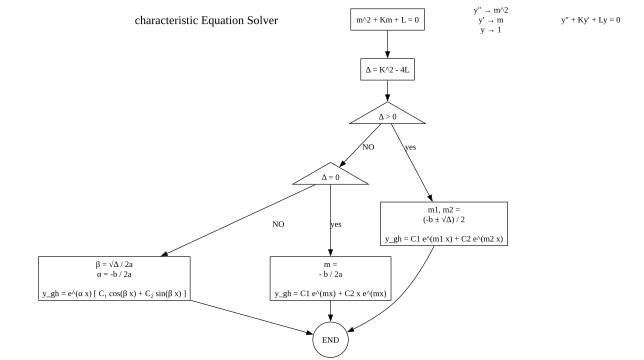

In [4]:
dot = Digraph(engine='dot')
dot.attr(size='9,5', ratio='fill')

dot.node('Title', 'characteristic Equation Solver', shape='plaintext', fontsize='20')

dot.node('A', 'm^2 + Km + L = 0', shape='rectangle') 
dot.node('B', 'Δ = K^2 - 4L', shape='rectangle') 
dot.node('C', 'Δ > 0', shape='triangle') 
dot.node('D', 'Δ = 0', shape='triangle') 
dot.node('E', 'β = √Δ / 2a\nα = -b / 2a\n\ny_gh = e^(α x) [ C₁ cos(β x) + C₂ sin(β x) ]',shape='rectangle') 
dot.node('F', 'END', shape='circle') 
dot.node('G', 'm1, m2 = \n(-b ± √Δ) / 2\n\ny_gh = C1 e^(m1 x) + C2 e^(m2 x)', shape='rectangle') 
dot.node('H', 'm = \n- b / 2a\n\ny_gh = C1 e^(mx) + C2 x e^(mx)', shape='rectangle')

dot.edge('A', 'B') 
dot.edge('B', 'C') 
dot.edge('C', 'D', label='NO') 
dot.edge('D', 'E', label='NO') 
dot.edge('E', 'F') 
dot.edge('C', 'G', label='yes') 
dot.edge('D', 'H', label='yes') 
dot.edge('G', 'F') 
dot.edge('H', 'F')

dot.node('label_right', 'y\u2033 \u2192 m^2\n y\u2032 \u2192 m\n y \u2192 1', shape='plaintext', width='0.1', height='0.1')
dot.node('label_left', 'y\u2033 + Ky\u2032 + Ly = 0', shape='plaintext', width='0.1', height='0.1', pos='-0.5,5!')

dot.render(downloads_path, format='png', cleanup=True)
dot

In [5]:
x = symbols('x') 
y = Function('y') 
C1, C2 = symbols('C1 C2')

a, b, c = 1, -4, 4
eq = Eq(a*Derivative(y(x), x, x) + b*Derivative(y(x), x) + c*y(x), 0)

r = symbols('r') 
char_eq = Eq(a*r**2 + b*r + c, 0) 
roots = solve(char_eq, r)

Delta = b**2 - 4*a*c

if Delta > 0:
    m1, m2 = roots 
    y_gh = C1 * exp(m1 * x) + C2 * exp(m2 * x) 
    print(f"m1: {m1}, m2: {m2}") 
    print(f"y_gh: {y_gh}")
    
elif Delta == 0:
    m = roots[0] 
    y_gh = (C1 + C2 * x) * exp(m * x) 
    print(f"m1 = m2: {m}") 
    print(f"y_gh: {y_gh}")
        
else:
    alpha = roots[0].as_real_imag()[0] 
    beta = abs(roots[0].as_real_imag()[1]) 
    y_gh = C1 * exp(alpha * x) * cos(beta * x) + C2 * exp(alpha * x) * sin(beta * x) 
    print(f"alpha: {alpha}, beta: {beta}") 
    print(f"y_gh: {y_gh}")

m1 = m2: 2
y_gh: (C1 + C2*x)*exp(2*x)


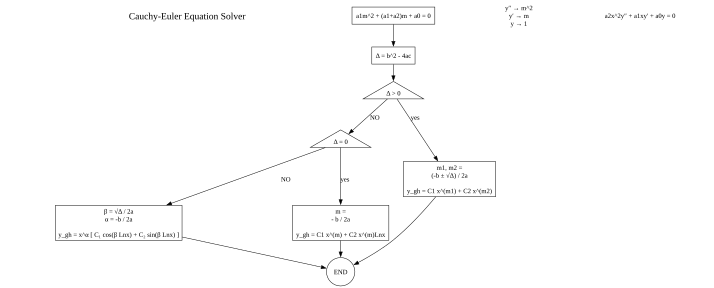

In [6]:
dot = Digraph(engine='dot')
dot.attr(size='10,4', ratio='fill')

dot.node('Title', 'Cauchy-Euler Equation Solver', shape='plaintext', fontsize='20')

dot.node('A', 'a1m^2 + (a1+a2)m + a0 = 0', shape='rectangle') 
dot.node('B', 'Δ = b^2 - 4ac', shape='rectangle') 
dot.node('C', 'Δ > 0', shape='triangle') 
dot.node('D', 'Δ = 0', shape='triangle') 
dot.node('E', 'β = √Δ / 2a\nα = -b / 2a\n\ny_gh = x^α [ C₁ cos(β Lnx) + C₂ sin(β Lnx) ]',shape='rectangle') 
dot.node('F', 'END', shape='circle') 
dot.node('G', 'm1, m2 = \n(-b ± √Δ) / 2a\n\ny_gh = C1 x^(m1) + C2 x^(m2)', shape='rectangle') 
dot.node('H', 'm = \n- b / 2a\n\ny_gh = C1 x^(m) + C2 x^(m)Lnx', shape='rectangle')

dot.edge('A', 'B') 
dot.edge('B', 'C') 
dot.edge('C', 'D', label='NO') 
dot.edge('D', 'E', label='NO') 
dot.edge('E', 'F') 
dot.edge('C', 'G', label='yes') 
dot.edge('D', 'H', label='yes') 
dot.edge('G', 'F') 
dot.edge('H', 'F')

dot.node('label_right', 'y\u2033 \u2192 m^2\n y\u2032 \u2192 m\n y \u2192 1', shape='plaintext', width='0.1', height='0.1')
dot.node('label_left', 'a2x^2y\u2033 + a1xy\u2032 + a0y = 0', shape='plaintext', width='0.1', height='0.1', pos='-0.5,5!')

dot.render(downloads_path, format='png', cleanup=True)
dot

In [7]:
x = symbols('x')
y = Function('y')
C1, C2 = symbols('C1 C2')

a, b, c = 1, 3, 1

eq = Eq(a * x**2 * Derivative(y(x), x, x) + b * x * Derivative(y(x), x) + c * y(x), 0)

r = symbols('r')
char_eq = Eq(a * r**2 + (b - a) * r + c, 0)
roots = solve(char_eq, r)

Delta = (b - a)**2 - 4 * a * c

if Delta > 0:
    m1, m2 = roots
    y_gh = C1 * x**m1 + C2 * x**m2
    print(f"m1: {m1}, m2: {m2}")
    print(f"y_gh: {y_gh}")
elif Delta == 0:
    m = roots[0]
    y_gh = (C1 + C2 * symbols('ln(x)')) * x**m
    print(f"m1 = m2: {m}")
    print(f"y_gh: {y_gh}")
else:
    alpha = roots[0].as_real_imag()[0]
    beta = abs(roots[0].as_real_imag()[1])
    y_gh = x**alpha * (C1 * cos(beta * symbols('ln(x)')) + C2 * sin(beta * symbols('ln(x)')))
    print(f"alpha: {alpha}, beta: {beta}")
    print(f"y_gh: {y_gh}")

m1 = m2: -1
y_gh: (C1 + C2*ln(x))/x
